In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
import torchvision.transforms as transforms
from torchvision import datasets
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# =========================================================
# DEVICE
# =========================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# =========================================================
# DATA AUGMENTATION & TRANSFORMS
# =========================================================

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# =========================================================
# LOAD DATASET
# =========================================================

full_dataset = datasets.ImageFolder(
    root="dataset",
    transform=eval_transform
)

dataset_size = len(full_dataset)
train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size

generator = torch.Generator().manual_seed(42)
indices = torch.randperm(dataset_size, generator=generator).tolist()
train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]
test_indices = indices[train_size + val_size:]

train_dataset = Subset(
    datasets.ImageFolder(root="dataset", transform=train_transform),
    train_indices
)

val_dataset = Subset(
    datasets.ImageFolder(root="dataset", transform=eval_transform),
    val_indices
)

test_dataset = Subset(
    datasets.ImageFolder(root="dataset", transform=eval_transform),
    test_indices
)

# =========================================================
# DATALOADERS
# =========================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

# =========================================================
# INFO
# =========================================================

num_classes = len(full_dataset.classes)

print("Classes:", full_dataset.classes)
print("Number of classes:", num_classes)
print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))


Using device: cpu
Classes: ['Angry', 'Other', 'Sad', 'happy']
Number of classes: 4
Train size: 700
Validation size: 150
Test size: 150


Epoch [1/20]: 100%|██████████| 22/22 [01:25<00:00,  3.88s/it, loss=1.42]



Epoch 1/20
Train Loss: 1.4540
Train Accuracy: 28.71%
Validation Loss: 1.3738
Validation Accuracy: 30.67%


Epoch [2/20]: 100%|██████████| 22/22 [01:21<00:00,  3.72s/it, loss=1.45]



Epoch 2/20
Train Loss: 1.4574
Train Accuracy: 26.86%
Validation Loss: 1.4106
Validation Accuracy: 24.67%


Epoch [3/20]: 100%|██████████| 22/22 [01:22<00:00,  3.75s/it, loss=1.51]


...


Epoch 18/20
Train Loss: 1.2204
Train Accuracy: 44.14%
Validation Loss: 1.3208
Validation Accuracy: 42.67%


Epoch [19/20]: 100%|██████████| 22/22 [01:33<00:00,  4.26s/it, loss=1.16]



Epoch 19/20
Train Loss: 1.1950
Train Accuracy: 47.14%
Validation Loss: 1.2987
Validation Accuracy: 42.00%


Epoch [20/20]: 100%|██████████| 22/22 [01:33<00:00,  4.26s/it, loss=1.29]



Epoch 20/20
Train Loss: 1.2213
Train Accuracy: 44.14%
Validation Loss: 1.3531
Validation Accuracy: 39.33%

================ RESULTS ================

Accuracy  : 36.67%
Weighted Precision : 0.3578
Weighted Recall    : 0.3667
Weighted F1 Score  : 0.3525

Classification Report:

Class                Precision    Recall  F1-score   Support
------------------------------------------------------------
Angry                   0.4237    0.6098    0.5000        41
Other                   0.3125    0.3333    0.3226        30
Sad                     0.3333    0.2955    0.3133        44
happy                   0.3500    0.2000    0.2545        35


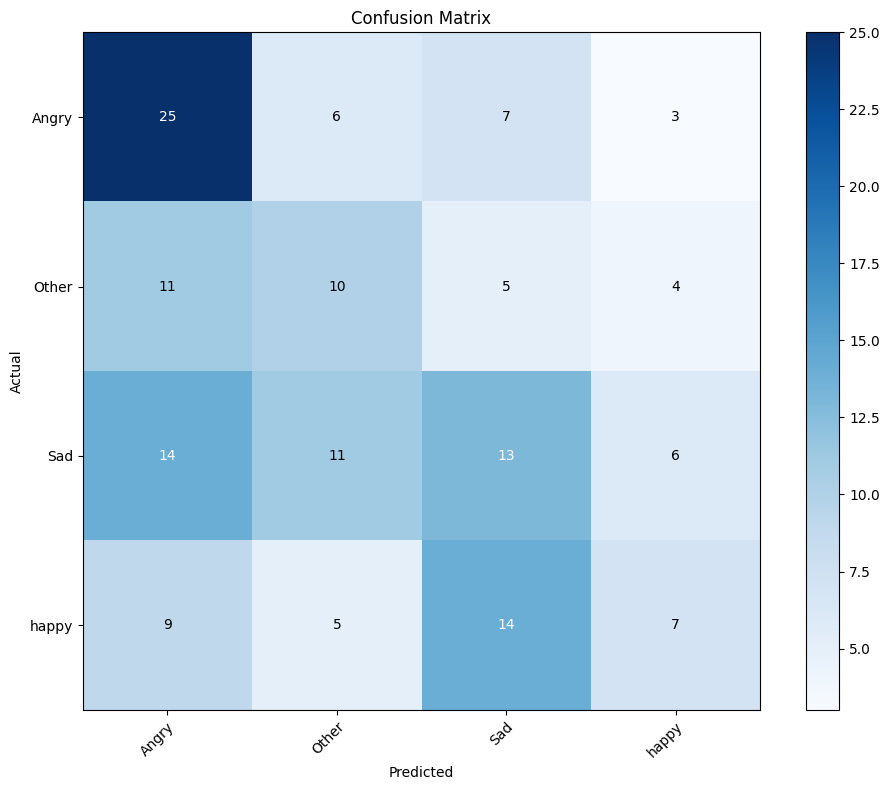


MobileNet Model Saved!


In [8]:
# =========================================================
# MOBILE NET FROM SCRATCH
# =========================================================

class DepthwiseSeparableConv(nn.Module):

    def __init__(self, in_channels, out_channels, stride=1):

        super(DepthwiseSeparableConv, self).__init__()

        self.depthwise = nn.Sequential(

            nn.Conv2d(
                in_channels,
                in_channels,
                kernel_size=3,
                stride=stride,
                padding=1,
                groups=in_channels,
                bias=False
            ),

            nn.BatchNorm2d(in_channels),

            nn.ReLU(inplace=True)
        )

        self.pointwise = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1,
                bias=False
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        x = self.depthwise(x)

        x = self.pointwise(x)

        return x

# =========================================================
# MOBILE NET MODEL
# =========================================================

class MobileNet(nn.Module):

    def __init__(self, num_classes):

        super(MobileNet, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(inplace=True),

            DepthwiseSeparableConv(32, 64, 1),

            DepthwiseSeparableConv(64, 128, 2),
            DepthwiseSeparableConv(128, 128, 1),

            DepthwiseSeparableConv(128, 256, 2),
            DepthwiseSeparableConv(256, 256, 1),

            DepthwiseSeparableConv(256, 512, 2),

            DepthwiseSeparableConv(512, 512, 1),
            DepthwiseSeparableConv(512, 512, 1),
            DepthwiseSeparableConv(512, 512, 1),
            DepthwiseSeparableConv(512, 512, 1),
            DepthwiseSeparableConv(512, 512, 1),

            DepthwiseSeparableConv(512, 1024, 2),

            DepthwiseSeparableConv(1024, 1024, 1)
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(1024, num_classes)

    def forward(self, x):

        x = self.features(x)

        x = self.pool(x)

        x = torch.flatten(x, 1)

        x = self.dropout(x)

        x = self.fc(x)

        return x

# =========================================================
# CREATE MODEL
# =========================================================

mobilenet_model = MobileNet(num_classes=num_classes).to(device)

# =========================================================
# LOSS FUNCTION
# =========================================================

criterion = nn.CrossEntropyLoss()

# =========================================================
# OPTIMIZER
# =========================================================

mobilenet_optimizer = optim.Adam(
    mobilenet_model.parameters(),
    lr=0.001
)

# =========================================================
# TRAIN FUNCTION
# =========================================================

def train_model(model, optimizer, train_loader, val_loader, epochs):

    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):

        model.train()

        running_loss = 0
        correct = 0
        total = 0

        loop = tqdm(train_loader)

        for images, labels in loop:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            loop.set_description(f"Epoch [{epoch+1}/{epochs}]")
            loop.set_postfix(loss=loss.item())

        train_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct / total

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        model.eval()

        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_accuracy = 100 * val_correct / val_total

        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Train Accuracy: {train_accuracy:.2f}%")
        print(f"Validation Loss: {val_loss:.4f}")
        print(f"Validation Accuracy: {val_accuracy:.2f}%")

    return train_losses, val_losses, train_accuracies, val_accuracies

# =========================================================
# METRICS HELPERS
# =========================================================

def compute_confusion_matrix(labels, preds, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for true, pred in zip(labels, preds):
        cm[true, pred] += 1
    return cm


def compute_precision_recall_f1(cm):
    tp = np.diag(cm).astype(float)
    support = cm.sum(axis=1).astype(float)
    predicted = cm.sum(axis=0).astype(float)

    precision = np.divide(tp, predicted, out=np.zeros_like(tp), where=predicted != 0)
    recall = np.divide(tp, support, out=np.zeros_like(tp), where=support != 0)
    f1 = np.divide(
        2 * precision * recall,
        precision + recall,
        out=np.zeros_like(precision),
        where=(precision + recall) != 0
    )

    total = support.sum()
    weighted_precision = np.dot(precision, support) / total if total > 0 else 0.0
    weighted_recall = np.dot(recall, support) / total if total > 0 else 0.0
    weighted_f1 = np.dot(f1, support) / total if total > 0 else 0.0

    return precision, recall, f1, weighted_precision, weighted_recall, weighted_f1


def format_classification_report(cm, class_names):
    precision, recall, f1, _, _, _ = compute_precision_recall_f1(cm)
    support = cm.sum(axis=1)

    lines = []
    lines.append(f"{'Class':<20}{'Precision':>10}{'Recall':>10}{'F1-score':>10}{'Support':>10}")
    lines.append('-' * 60)

    for idx, label in enumerate(class_names):
        lines.append(
            f"{label:<20}{precision[idx]:>10.4f}{recall[idx]:>10.4f}{f1[idx]:>10.4f}{support[idx]:>10d}"
        )

    return '\n'.join(lines)

# =========================================================
# EVALUATION FUNCTION
# =========================================================
def evaluate_model(model, test_loader, class_names):

    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = compute_confusion_matrix(all_labels, all_preds, len(class_names))
    precision, recall, f1, weighted_precision, weighted_recall, weighted_f1 = compute_precision_recall_f1(cm)
    accuracy = 100 * np.mean(np.array(all_preds) == np.array(all_labels))

    print("\n================ RESULTS ================\n")
    print(f"Accuracy  : {accuracy:.2f}%")
    print(f"Weighted Precision : {weighted_precision:.4f}")
    print(f"Weighted Recall    : {weighted_recall:.4f}")
    print(f"Weighted F1 Score  : {weighted_f1:.4f}\n")

    print("Classification Report:\n")
    print(format_classification_report(cm, class_names))

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    fig.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        ylabel='Actual',
        xlabel='Predicted',
        title='Confusion Matrix'
    )

    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

    thresh = cm.max() / 2.0 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = 'white' if cm[i, j] > thresh else 'black'
            ax.text(j, i, format(cm[i, j], 'd'), ha='center', va='center', color=color)

    plt.tight_layout()
    plt.show()

# =========================================================
# TRAIN MOBILE NET
# =========================================================

mobilenet_train_losses, mobilenet_val_losses, mobilenet_train_acc, mobilenet_val_acc = train_model(
    mobilenet_model,
    mobilenet_optimizer,
    train_loader,
    val_loader,
    epochs=20
)

# =========================================================
# EVALUATE MOBILE NET
# =========================================================

evaluate_model(
    mobilenet_model,
    test_loader,
    full_dataset.classes
)

# =========================================================
# SAVE MODEL
# =========================================================

torch.save(
    mobilenet_model.state_dict(),
    "mobilenet_scratch.pth"
)

print("\nMobileNet Model Saved!")


Epoch [1/20]: 100%|██████████| 22/22 [03:06<00:00,  8.49s/it, loss=1.97]



Epoch 1/20
Train Loss: 2.0452 | Train Accuracy: 28.43%
Val Loss: 1.3976 | Val Accuracy: 24.67%


Epoch [2/20]: 100%|██████████| 22/22 [03:12<00:00,  8.75s/it, loss=1.89]



Epoch 2/20
Train Loss: 1.9558 | Train Accuracy: 29.14%
Val Loss: 1.3911 | Val Accuracy: 27.33%


Epoch [3/20]: 100%|██████████| 22/22 [03:11<00:00,  8.71s/it, loss=1.95]


...


Epoch 18/20
Train Loss: 1.8586 | Train Accuracy: 35.00%
Val Loss: 1.3404 | Val Accuracy: 34.67%


Epoch [19/20]: 100%|██████████| 22/22 [02:31<00:00,  6.90s/it, loss=2.04]



Epoch 19/20
Train Loss: 1.7714 | Train Accuracy: 37.29%
Val Loss: 1.4742 | Val Accuracy: 36.00%


Epoch [20/20]: 100%|██████████| 22/22 [02:30<00:00,  6.85s/it, loss=2.09]



Epoch 20/20
Train Loss: 1.8156 | Train Accuracy: 36.43%
Val Loss: 1.3620 | Val Accuracy: 36.00%

================ RESULTS ================

Accuracy  : 32.00%
Weighted Precision : 0.3000
Weighted Recall    : 0.3200
Weighted F1 Score  : 0.2800

Classification Report:

Class                Precision    Recall  F1-score   Support
------------------------------------------------------------
Angry                   0.4167    0.4878    0.4494        41
Other                   0.1935    0.2000    0.1967        30
Sad                     0.2500    0.0455    0.0769        44
happy                   0.3175    0.5714    0.4082        35


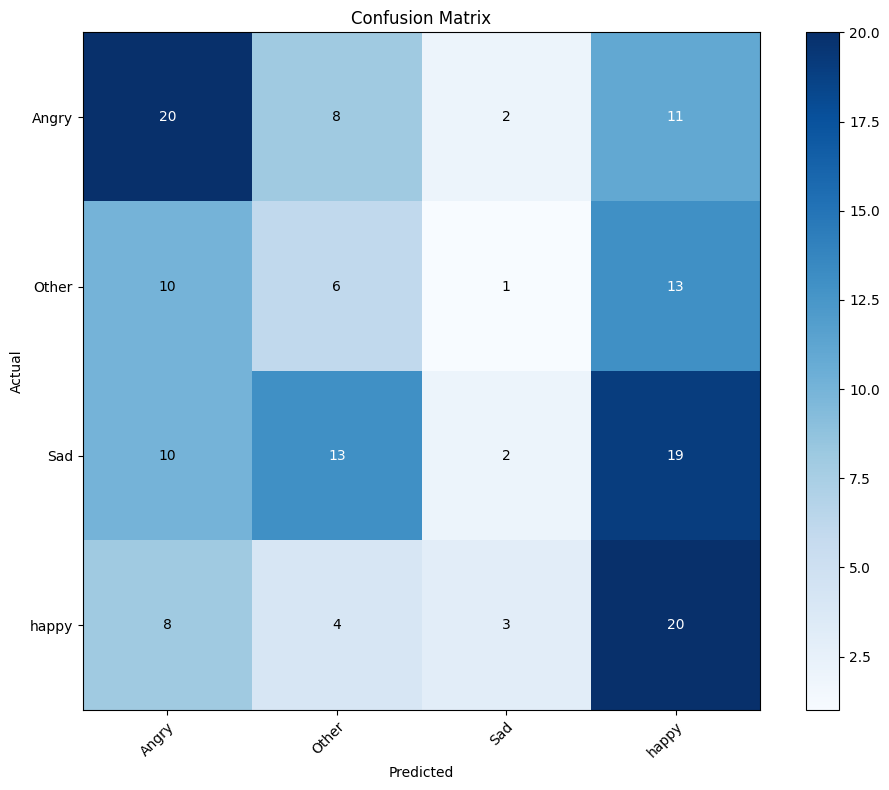


InceptionV3 Model Saved!


In [10]:
class BasicConv(nn.Module):
    def __init__(self, in_channels, out_channels, **kwargs):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, bias=False, **kwargs)
        self.bn = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        return torch.relu(self.bn(self.conv(x)))


class InceptionA(nn.Module):
    def __init__(self, in_channels, pool_features):
        super().__init__()
        self.branch1 = BasicConv(in_channels, 64, kernel_size=1)
        self.branch2 = nn.Sequential(
            BasicConv(in_channels, 48, kernel_size=1),
            BasicConv(48, 64, kernel_size=3, padding=1)
        )
        self.branch3 = nn.Sequential(
            BasicConv(in_channels, 64, kernel_size=1),
            BasicConv(64, 96, kernel_size=3, padding=1),
            BasicConv(96, 96, kernel_size=3, padding=1)
        )
        self.branch4 = nn.Sequential(
            nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
            BasicConv(in_channels, pool_features, kernel_size=1)
        )

    def forward(self, x):
        return torch.cat([self.branch1(x), self.branch2(x), self.branch3(x), self.branch4(x)], 1)


class InceptionB(nn.Module):
    def __init__(self, in_channels, channels_7x7):
        super().__init__()
        c7 = channels_7x7
        self.branch1 = BasicConv(in_channels, 192, kernel_size=1)
        self.branch2 = nn.Sequential(
            BasicConv(in_channels, c7, kernel_size=1),
            BasicConv(c7, c7, kernel_size=(1, 7), padding=(0, 3)),
            BasicConv(c7, 192, kernel_size=(7, 1), padding=(3, 0))
        )
        self.branch3 = nn.Sequential(
            BasicConv(in_channels, c7, kernel_size=1),
            BasicConv(c7, c7, kernel_size=(7, 1), padding=(3, 0)),
            BasicConv(c7, c7, kernel_size=(1, 7), padding=(0, 3)),
            BasicConv(c7, c7, kernel_size=(7, 1), padding=(3, 0)),
            BasicConv(c7, 192, kernel_size=(1, 7), padding=(0, 3))
        )
        self.branch4 = nn.Sequential(
            nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
            BasicConv(in_channels, 192, kernel_size=1)
        )

    def forward(self, x):
        return torch.cat([self.branch1(x), self.branch2(x), self.branch3(x), self.branch4(x)], 1)


class InceptionC(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.branch1 = BasicConv(in_channels, 320, kernel_size=1)
        self.branch2_reduce = BasicConv(in_channels, 384, kernel_size=1)
        self.branch2a = BasicConv(384, 384, kernel_size=(1, 3), padding=(0, 1))
        self.branch2b = BasicConv(384, 384, kernel_size=(3, 1), padding=(1, 0))
        self.branch3_reduce = nn.Sequential(
            BasicConv(in_channels, 448, kernel_size=1),
            BasicConv(448, 384, kernel_size=3, padding=1)
        )
        self.branch3a = BasicConv(384, 384, kernel_size=(1, 3), padding=(0, 1))
        self.branch3b = BasicConv(384, 384, kernel_size=(3, 1), padding=(1, 0))
        self.branch4 = nn.Sequential(
            nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
            BasicConv(in_channels, 192, kernel_size=1)
        )

    def forward(self, x):
        b1 = self.branch1(x)
        b2 = self.branch2_reduce(x)
        b2 = torch.cat([self.branch2a(b2), self.branch2b(b2)], 1)
        b3 = self.branch3_reduce(x)
        b3 = torch.cat([self.branch3a(b3), self.branch3b(b3)], 1)
        b4 = self.branch4(x)
        return torch.cat([b1, b2, b3, b4], 1)


class ReductionA(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.branch1 = BasicConv(in_channels, 384, kernel_size=3, stride=2, padding=1)
        self.branch2 = nn.Sequential(
            BasicConv(in_channels, 64, kernel_size=1),
            BasicConv(64, 96, kernel_size=3, padding=1),
            BasicConv(96, 96, kernel_size=3, stride=2, padding=1)
        )
        self.branch3 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

    def forward(self, x):
        return torch.cat([self.branch1(x), self.branch2(x), self.branch3(x)], 1)


class ReductionB(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.branch1 = nn.Sequential(
            BasicConv(in_channels, 192, kernel_size=1),
            BasicConv(192, 320, kernel_size=3, stride=2, padding=1)
        )
        self.branch2 = nn.Sequential(
            BasicConv(in_channels, 192, kernel_size=1),
            BasicConv(192, 192, kernel_size=(1, 7), padding=(0, 3)),
            BasicConv(192, 192, kernel_size=(7, 1), padding=(3, 0)),
            BasicConv(192, 192, kernel_size=3, stride=2, padding=1)
        )
        self.branch3 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

    def forward(self, x):
        return torch.cat([self.branch1(x), self.branch2(x), self.branch3(x)], 1)


class AuxClassifier(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d((4, 4))
        self.conv1 = BasicConv(in_channels, 128, kernel_size=1)
        self.conv2 = BasicConv(128, 768, kernel_size=4)
        self.fc = nn.Linear(768, num_classes)

    def forward(self, x):
        x = self.pool(x)
        x = self.conv1(x)
        x = self.conv2(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


class InceptionV3(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.stem = nn.Sequential(
            BasicConv(3, 32, kernel_size=3, stride=2, padding=1),
            BasicConv(32, 32, kernel_size=3, padding=1),
            BasicConv(32, 64, kernel_size=3, padding=1),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            BasicConv(64, 80, kernel_size=1),
            BasicConv(80, 192, kernel_size=3, padding=1),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        self.inceptionA1 = InceptionA(192, pool_features=32)
        self.inceptionA2 = InceptionA(256, pool_features=64)
        self.inceptionA3 = InceptionA(288, pool_features=64)
        self.reductionA  = ReductionA(288)
        self.inceptionB1 = InceptionB(768, channels_7x7=128)
        self.inceptionB2 = InceptionB(768, channels_7x7=160)
        self.inceptionB3 = InceptionB(768, channels_7x7=160)
        self.inceptionB4 = InceptionB(768, channels_7x7=192)
        self.aux         = AuxClassifier(768, num_classes)
        self.reductionB  = ReductionB(768)
        self.inceptionC1 = InceptionC(1280)
        self.inceptionC2 = InceptionC(2048)
        self.pool        = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout     = nn.Dropout(0.5)
        self.fc          = nn.Linear(2048, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.inceptionA1(x)
        x = self.inceptionA2(x)
        x = self.inceptionA3(x)
        x = self.reductionA(x)
        x = self.inceptionB1(x)
        x = self.inceptionB2(x)
        x = self.inceptionB3(x)
        x = self.inceptionB4(x)
        aux_out = self.aux(x)
        x = self.reductionB(x)
        x = self.inceptionC1(x)
        x = self.inceptionC2(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        return self.fc(x), aux_out


inception_model = InceptionV3(num_classes=num_classes).to(device)

inception_optimizer = optim.Adam(inception_model.parameters(), lr=0.001)


def train_inception(model, optimizer, train_loader, val_loader, epochs):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        correct = 0
        total = 0
        loop = tqdm(train_loader)

        for images, labels in loop:
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            main_out, aux_out = model(images)
            loss = criterion(main_out, labels) + 0.4 * criterion(aux_out, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(main_out, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            loop.set_description(f"Epoch [{epoch+1}/{epochs}]")
            loop.set_postfix(loss=loss.item())

        train_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct / total
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                main_out, _ = model(images)
                loss = criterion(main_out, labels)
                val_loss += loss.item()
                _, predicted = torch.max(main_out, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_accuracy = 100 * val_correct / val_total
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.2f}%")
        print(f"Val Loss: {val_loss:.4f} | Val Accuracy: {val_accuracy:.2f}%")

    return train_losses, val_losses, train_accuracies, val_accuracies


def evaluate_inception(model, test_loader, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            main_out, _ = model(images)
            _, predicted = torch.max(main_out, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = compute_confusion_matrix(all_labels, all_preds, len(class_names))
    precision, recall, f1, weighted_precision, weighted_recall, weighted_f1 = compute_precision_recall_f1(cm)
    accuracy = 100 * np.mean(np.array(all_preds) == np.array(all_labels))

    print("\n================ RESULTS ================\n")
    print(f"Accuracy  : {accuracy:.2f}%")
    print(f"Weighted Precision : {weighted_precision:.4f}")
    print(f"Weighted Recall    : {weighted_recall:.4f}")
    print(f"Weighted F1 Score  : {weighted_f1:.4f}\n")
    print("Classification Report:\n")
    print(format_classification_report(cm, class_names))

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    fig.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        ylabel='Actual',
        xlabel='Predicted',
        title='Confusion Matrix'
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
    thresh = cm.max() / 2.0 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = 'white' if cm[i, j] > thresh else 'black'
            ax.text(j, i, format(cm[i, j], 'd'), ha='center', va='center', color=color)
    plt.tight_layout()
    plt.show()


inception_train_losses, inception_val_losses, inception_train_acc, inception_val_acc = train_inception(
    inception_model,
    inception_optimizer,
    train_loader,
    val_loader,
    epochs=20
)

evaluate_inception(inception_model, test_loader, full_dataset.classes)

torch.save(inception_model.state_dict(), "inceptionv3_scratch.pth")

print("\nInceptionV3 Model Saved!")
